In [1]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

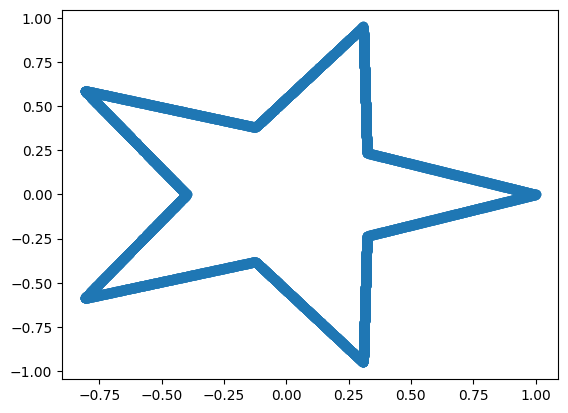

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [3]:
class Config:
    sigma_min = 0.01
    sigma_max = 4.0

    lr = 1e-3
    epochs = 2000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

In [4]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [5]:
def sigma_t(t, config):
    return config.sigma_min * (config.sigma_max / config.sigma_min) ** t

def g_t(t, config):
    sigma = sigma_t(t, config)
    c = math.sqrt(2.0 * math.log(config.sigma_max / config.sigma_min))

    return sigma * c

In [6]:
class VETrainer():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            sigma = sigma_t(t, self.config)

            z = torch.randn_like(batch)
            x_t = batch + sigma * z

            pred_z = self.model(x_t, t)
            # loss = ((sigma * pred_z + z) ** 2).sum(dim=1).mean()
            loss = F.mse_loss(pred_z, z)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            if n % 100 == 0:
                print(f'Loss: {loss}')

In [7]:
config = Config()
trainer = VETrainer(config)

In [8]:
trainer.run()

Loss: 0.8895687858581542
Loss: 0.6608122563362122
Loss: 0.6419487126350403
Loss: 0.6164037161827087
Loss: 0.6245582582473755
Loss: 0.5962333863258362
Loss: 0.5846521237373352
Loss: 0.5985106641769409
Loss: 0.5829213264465332
Loss: 0.5766440061569214
Loss: 0.5762053082466125
Loss: 0.5746411894798279
Loss: 0.5567747174263
Loss: 0.5334001645565033
Loss: 0.5362767576217652
Loss: 0.5393379232406617
Loss: 0.5497836829185486
Loss: 0.5332093572616577
Loss: 0.5426449380874634
Loss: 0.5420945520877838


In [9]:
def sample(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device) * config.sigma_max

        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 1e-6)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            sigma = sigma_t(t_tensor, config)
            gt = g_t(t_tensor, config)

            pred = model(x, t_tensor)
            score = -pred / sigma

            drift = (gt ** 2) * score * dt
            diffusion = gt * torch.randn_like(x) * math.sqrt(dt)

            x = x + drift + diffusion

        return x.cpu().numpy()

In [10]:
samples = sample(trainer.model, trainer.config, 1000)

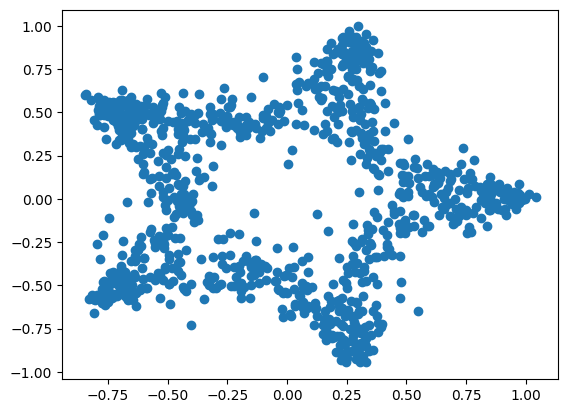

In [11]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

## VP-SDE

Теперь мы реализуем Variance-Preserving SDE (VP-SDE) — вариант диффузионных моделей, сохраняющий дисперсию.
В отличие от VE-SDE, VP-SDE удерживает variance в заданных границах, правильно масштабируя сигнал и шум.
Мы исследуем два noise schedule'а (линейный и косинусный) и три схемы взвешивания loss'а.

In [12]:
def linear_alpha_bar(t, b_min=0.1, b_max=20.0):
    area = b_min * t + 0.5 * (b_max - b_min) * t ** 2
    return torch.clamp(torch.exp(-area), min=1e-5, max=1.0 - 1e-5)

def linear_beta(t, b_min=0.1, b_max=20.0):
    return b_min + (b_max - b_min) * t

def cosine_alpha_bar(t, s=0.008):
    ang = (t + s) / (1.0 + s) * math.pi / 2.0
    f_zero = math.cos(s / (1.0 + s) * math.pi / 2.0) ** 2
    return torch.clamp(torch.cos(ang) ** 2 / f_zero, min=1e-5, max=1.0 - 1e-5)

def cosine_beta(t, s=0.008, beta_clip=20.0):
    ang = (t + s) / (1.0 + s) * math.pi / 2.0
    beta_val = math.pi / (1.0 + s) * torch.tan(ang)
    return torch.clamp(beta_val, min=1e-6, max=beta_clip)

SCHEDULES = {
    'linear': (linear_alpha_bar, linear_beta),
    'cosine': (cosine_alpha_bar, cosine_beta),
}

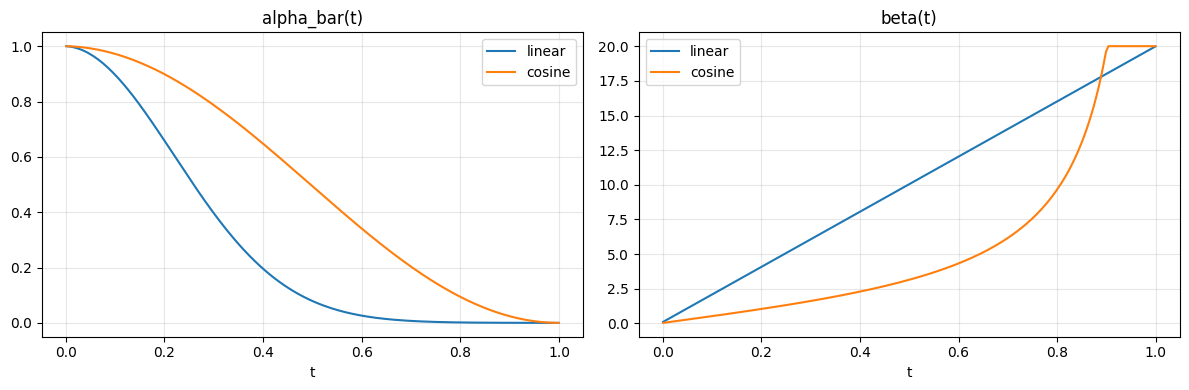

In [13]:
t_grid = torch.linspace(0.001, 0.999, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for sched_name, (ab_fn, b_fn) in SCHEDULES.items():
    ax1.plot(t_grid.numpy(), ab_fn(t_grid).numpy(), label=sched_name)
    ax2.plot(t_grid.numpy(), b_fn(t_grid).numpy(), label=sched_name)

ax1.set_title('alpha_bar(t)')
ax1.set_xlabel('t')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title('beta(t)')
ax2.set_xlabel('t')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## VP-SDE: взвешивание Loss'а

Различные схемы взвешивания denoising loss'а:
- **Uniform**: все timestep'ы взвешены одинаково
- **SNR**: взвешивание по signal-to-noise ratio (акцент на шагах с низким шумом)
- **Likelihood**: взвешивание по beta(t) (связь с ELBO)

In [14]:
def weight_uniform(ab, beta_val, t):
    return torch.ones_like(t)

def weight_snr(ab, beta_val, t):
    ratio = ab / (1.0 - ab + 1e-5)
    return torch.clamp(ratio, max=5.0)

def weight_likelihood(ab, beta_val, t):
    return beta_val

WEIGHTS = {
    'uniform': weight_uniform,
    'snr': weight_snr,
    'likelihood': weight_likelihood,
}

## VP-SDE: Trainer и Sampler

Класс `VPTrainer` реализует обучение для VP-SDE моделей.
Forward process задаётся формулой:

$$x_t = \sqrt{\bar{\alpha}(t)}\, x_0 + \sqrt{1 - \bar{\alpha}(t)}\, \epsilon$$

Мы обучаем score model предсказывать шум $\epsilon$, используя взвешивание loss'а, специфичное для выбранного schedule'а.

In [15]:
class VPTrainer():
    def __init__(self, config, ab_schedule, beta_schedule, loss_weight_fn):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
        self.ab_schedule = ab_schedule
        self.beta_schedule = beta_schedule
        self.loss_weight_fn = loss_weight_fn

        star_pts = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star_pts, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.loader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_step(self):
        self.model.train()
        running_loss = 0.0

        for (batch,) in self.loader:
            batch = batch.to(self.device)

            # Sample random timesteps
            t = torch.rand(batch.shape[0], 1, device=self.device)
            t = torch.clamp(t, min=1e-5, max=1.0 - 1e-5)

            ab = self.ab_schedule(t)
            beta = self.beta_schedule(t)
            noise_vec = torch.randn_like(batch)

            # Forward diffusion process
            noisy_x = torch.sqrt(ab) * batch + torch.sqrt(1.0 - ab) * noise_vec

            pred_noise = self.model(noisy_x, t)

            # Weighted MSE loss
            w = self.loss_weight_fn(ab, beta, t)
            loss = (w * (pred_noise - noise_vec) ** 2).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item() * batch.shape[0]

        return running_loss / len(self.data)

    def run(self):
        loss_history = []
        for epoch in range(self.config.epochs):
            current_loss = self.train_step()
            loss_history.append(current_loss)
            if epoch % 500 == 0:
                print(f'Epoch {epoch}: Loss = {current_loss:.6f}')
        return loss_history

In [16]:
def sample_vp(model, ab_schedule, beta_schedule, num_samples=1000, num_steps=1000):
    device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
        x_curr = torch.randn(num_samples, 2, device=device)
        step_size = 1.0 / num_steps

        for step_idx in range(num_steps):
            t_val = 1.0 - step_idx * step_size
            t_val = max(t_val, 1e-5)
            t_batch = torch.full((num_samples, 1), t_val, device=device)

            ab = ab_schedule(t_batch)
            beta = beta_schedule(t_batch)

            pred_noise = model(x_curr, t_batch)
            score = -pred_noise / torch.sqrt(1.0 - ab)

            drift = (0.5 * beta * x_curr + beta * score) * step_size

            if step_idx < num_steps - 1:
                diffusion = torch.sqrt(beta * step_size) * torch.randn_like(x_curr)
            else:
                diffusion = torch.zeros_like(x_curr)

            x_curr = x_curr + drift + diffusion

        return x_curr.cpu().numpy()

## Эксперименты: VP-SDE

Мы проводим grid поиск по комбинациям двух schedule'ов (linear, cosine) и трёх схем взвешивания (uniform, SNR, likelihood). Каждая конфигурация обучает отдельную score model и генерирует сэмплы для визуального сравнения.

In [17]:
cfg = Config()
all_results = {}

for schedule_name in ['linear', 'cosine']:
    for weighting_name in ['uniform', 'snr', 'likelihood']:
        run_name = f'{schedule_name}_{weighting_name}'
        print(f'\n=== Training: {run_name} ===')

        alpha_bar_fn, beta_fn = SCHEDULES[schedule_name]
        weighting_fn = WEIGHTS[weighting_name]

        vp_trainer = VPTrainer(cfg, alpha_bar_fn, beta_fn, weighting_fn)
        train_losses = vp_trainer.run()

        generated = sample_vp(
            vp_trainer.model, alpha_bar_fn, beta_fn,
            num_samples=1000,
            num_steps=cfg.num_timesteps
        )

        all_results[run_name] = {
            'model': vp_trainer.model,
            'losses': train_losses,
            'samples': generated,
            'schedule': schedule_name,
            'weighting': weighting_name,
        }
        print(f'Final loss: {train_losses[-1]:.6f}')


=== Training: linear_uniform ===
Epoch 0: Loss = 0.887863
Epoch 500: Loss = 0.166869
Epoch 1000: Loss = 0.155658
Epoch 1500: Loss = 0.151633
Final loss: 0.157942

=== Training: linear_snr ===
Epoch 0: Loss = 1.068327
Epoch 500: Loss = 0.607653
Epoch 1000: Loss = 0.602609
Epoch 1500: Loss = 0.513342
Final loss: 0.579669

=== Training: linear_likelihood ===
Epoch 0: Loss = 8.357413
Epoch 500: Loss = 0.460542
Epoch 1000: Loss = 0.445123
Epoch 1500: Loss = 0.435442
Final loss: 0.432210

=== Training: cosine_uniform ===
Epoch 0: Loss = 0.883753
Epoch 500: Loss = 0.294004
Epoch 1000: Loss = 0.291954
Epoch 1500: Loss = 0.289164
Final loss: 0.287482

=== Training: cosine_snr ===
Epoch 0: Loss = 1.995024
Epoch 500: Loss = 1.108698
Epoch 1000: Loss = 1.108459
Epoch 1500: Loss = 1.057213
Final loss: 1.135849

=== Training: cosine_likelihood ===
Epoch 0: Loss = 5.238381
Epoch 500: Loss = 0.453893
Epoch 1000: Loss = 0.451120
Epoch 1500: Loss = 0.443552
Final loss: 0.444389


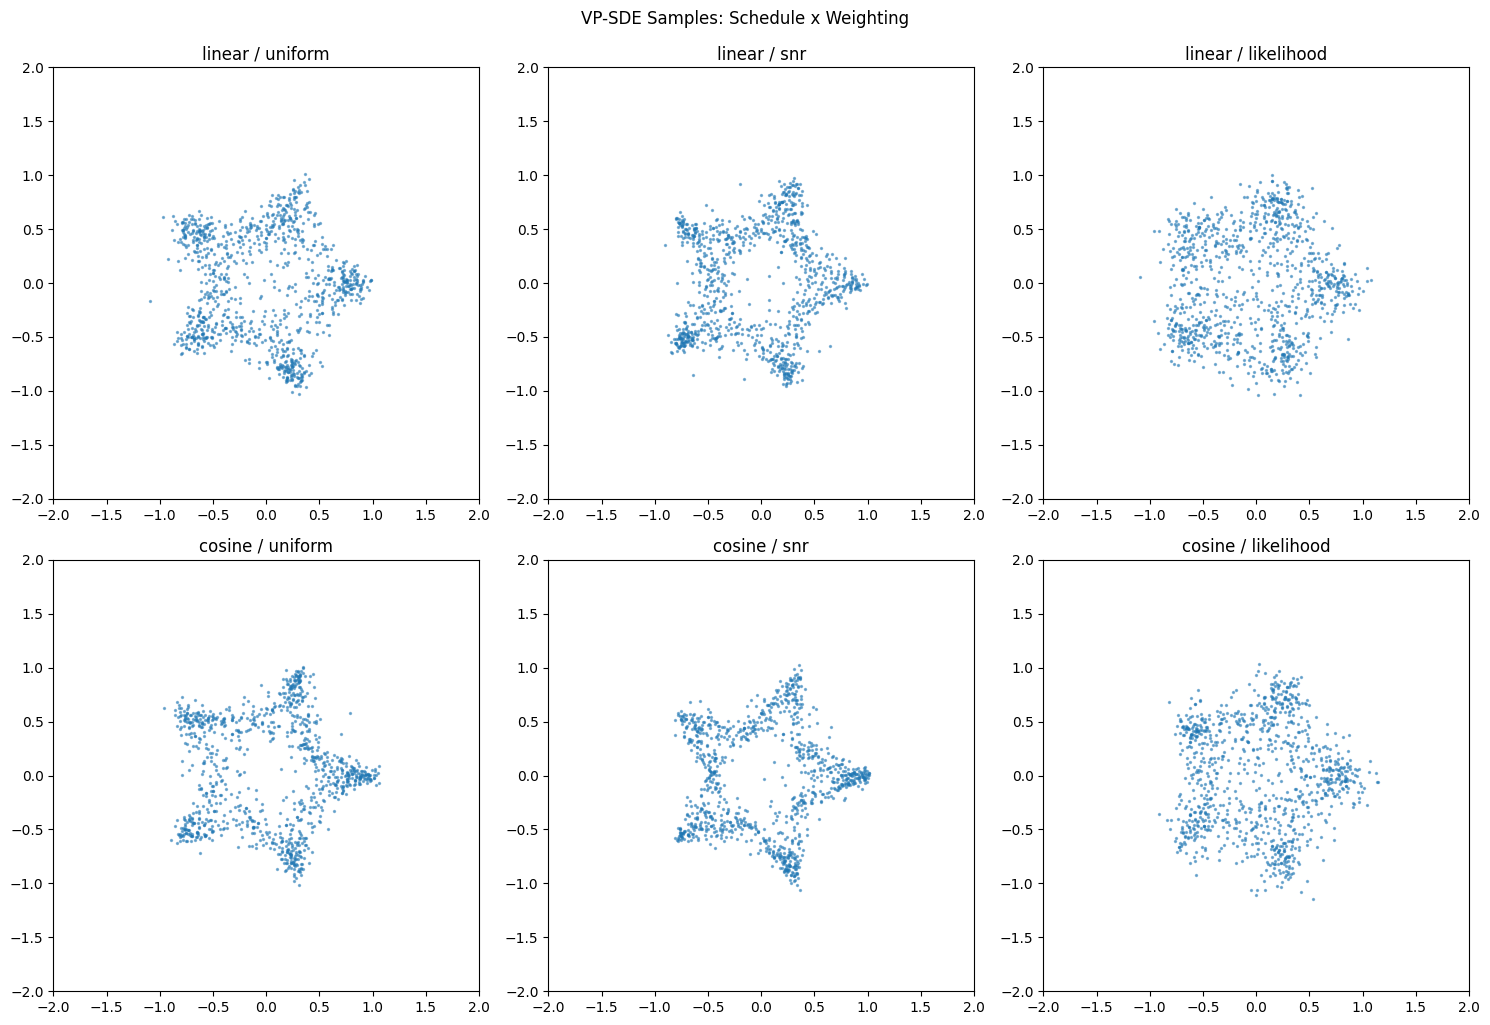

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (run_name, result) in enumerate(all_results.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row][col]
    pts = result['samples']
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.5)
    ax.set_title(f"{result['schedule']} / {result['weighting']}")
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

plt.tight_layout()
plt.suptitle('VP-SDE Samples: Schedule x Weighting', y=1.02)
plt.show()

## Сравнение расписаний: linear vs cosine

Сравниваем динамику loss-кривых для двух schedule при каждом типе взвешивания.

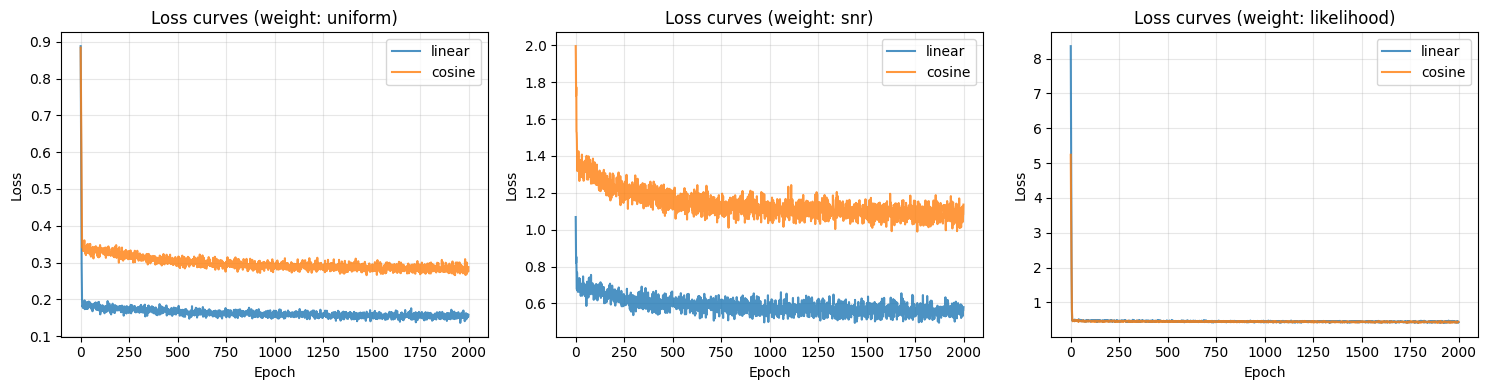

In [19]:
weight_names = ['uniform', 'snr', 'likelihood']
sched_names  = ['linear', 'cosine']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for j, weight in enumerate(weight_names):
    ax = axes[j]
    for sched in sched_names:
        exp = all_results[f'{sched}_{weight}']
        ax.plot(exp['losses'], label=sched, alpha=0.8)
    ax.set_title(f'Loss curves (weight: {weight})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Cosine schedule обеспечивает более плавное зашумление данных: `alpha_bar(t)` убывает медленно вначале и резко к концу, оставляя модели больше информации на промежуточных timesteps.

При **uniform-взвешивании** linear достигает более низкого числового loss (~0.158 vs ~0.287), однако визуально оба расписания уверенно восстанавливают форму звезды.

При **SNR-взвешивании** cosine показывает наибольший числовой loss (~1.14 vs ~0.58 у linear). Важно понимать: высокий loss здесь не означает плохое качество — это артефакт самого SNR-взвешивания, которое масштабирует градиенты на низко-зашумленных шагах. Визуально `cosine/snr` даёт **наилучший результат** из всех 6 комбинаций: самые чёткие лучи звезды.

При **likelihood-взвешивании** оба расписания стартуют с аномально высокого loss (8.4 и 5.2) из-за больших значений beta(t) вначале, но быстро сходятся к схожим значениям (~0.432 и ~0.444). Визуально оба варианта дают наихудший результат — форма звезды почти неразличима (blob-like).

## Сравнение loss weighting: uniform vs SNR vs likelihood

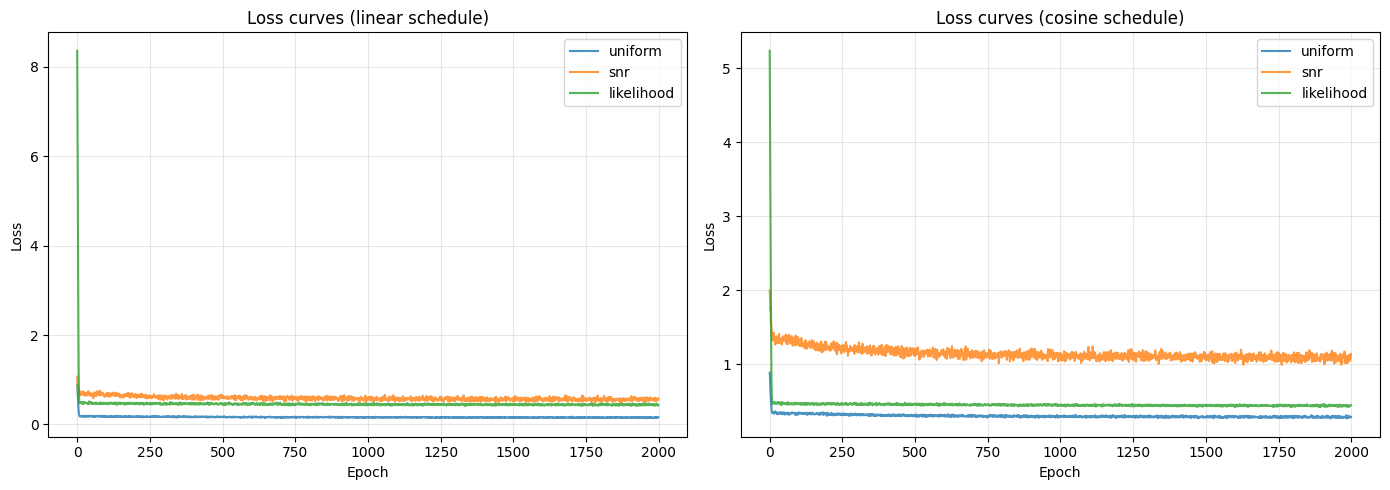

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, sched in enumerate(sched_names):
    ax = axes[i]
    for weight in weight_names:
        exp = all_results[f'{sched}_{weight}']
        ax.plot(exp['losses'], label=weight, alpha=0.8)
    ax.set_title(f'Loss curves ({sched} schedule)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Uniform**-взвешивание даёт наиболее стабильное обучение и наименьший числовой loss (~0.158 для linear, ~0.287 для cosine) — все timesteps вносят равный вклад. Визуально оба варианта уверенно восстанавливают форму звезды, хотя лучи менее чёткие, чем у SNR.

**SNR**-взвешивание акцентирует обучение на мало зашумленных шагах (низкий t), где SNR = alpha_bar / (1 − alpha_bar) высок. Это численно увеличивает loss (~0.58 для linear, ~1.14 для cosine), поскольку взвешивание масштабирует градиенты — но именно SNR даёт **лучшее визуальное качество**: кончики лучей звезды наиболее чёткие. `cosine/snr` — лучшая комбинация по качеству генерации.

**Likelihood**-взвешивание (по beta(t)) теоретически связано с ELBO. Оно акцентирует сильно зашумленные шаги, из-за чего loss на Epoch 0 аномально высок (8.4 и 5.2), но затем быстро сходится к ~0.43–0.44. Визуально это **наихудший вариант**: оба расписания дают blob-like распределение, форма звезды почти не угадывается. Фокус на ранних (шумных) шагах мешает модели выучить точную структуру данных.

## Вывод

VP-SDE диффузия успешно генерирует форму звезды при всех 6 комбинациях (2 schedule × 3 weighting). Ключевые наблюдения:

- **Linear vs Cosine schedule**: оба работают. Cosine обеспечивает более плавное зашумление — `alpha_bar(t)` убывает медленно вначале, что даёт модели лучший обучающий сигнал на промежуточных timesteps. При SNR-взвешивании именно `cosine/snr` показывает наилучшее визуальное качество.
- **Uniform weighting** — наиболее стабильный baseline: loss численно минимален, обучение предсказуемое. Хороший вариант по умолчанию.
- **SNR weighting** — несмотря на наибольший числовой loss (~0.58 для linear, ~1.14 для cosine), это **лучший вариант по визуальному качеству**: модель концентрируется на мало зашумленных шагах, где формируются тонкие детали структуры. Высокий loss — артефакт масштабирования весов, а не признак плохого обучения.
- **Likelihood weighting** — стартует с аномально высокого loss и сходится к среднему значению, но визуально показывает **наихудший результат**: оба варианта дают размытое blob-like облако вместо звезды. Фокус на сильно зашумленных шагах не позволяет модели выучить точную геометрию распределения.

**Лучшая комбинация**: `cosine / SNR` — чёткие лучи, наиболее структурированная звезда. Для задач, где важна стабильность обучения, предпочтителен `linear / uniform`.